In [1]:
import numpy as np
import pandas as pd

data_frame = pd.read_csv('data/Mall_Customers.csv')
df = data_frame.copy()
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [2]:
df.shape, df.columns.tolist()

((200, 5),
 ['CustomerID',
  'Genre',
  'Age',
  'Annual Income (k$)',
  'Spending Score (1-100)'])

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

sns.set_theme(style='whitegrid')

# 1) Select features for clustering
# We usually remove ID columns and keep meaningful numeric features.
cols_to_drop = [c for c in ['CustomerID', 'CustomerId', 'customerid', 'ID', 'Id'] if c in df.columns]
df_clust = df.drop(columns=cols_to_drop).copy()

# Keep numeric columns only (Age, Income, Spending Score...)
X = df_clust.select_dtypes(include=[np.number]).copy()

X.shape, X.columns.tolist()

((200, 3), ['Age', 'Annual Income (k$)', 'Spending Score (1-100)'])

# 1.14 Unsupervised Learning — Clustering (Mall Customers)

We will demonstrate clustering with *good practice* steps:
- Feature selection (choose the right columns)
- Scaling (StandardScaler)
- Choosing number of clusters **k** (Elbow + Silhouette)
- Final KMeans clustering + simple visualization
- (Optional) Hierarchical clustering (dendrogram)

## Step 1 — Scale the features
KMeans uses distances, so scaling is important when features have different units.

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled.shape

(200, 3)

## Step 2 — Choose number of clusters (Elbow Method)
We compute inertia (within-cluster SSE). The ‘elbow’ is a reasonable k.

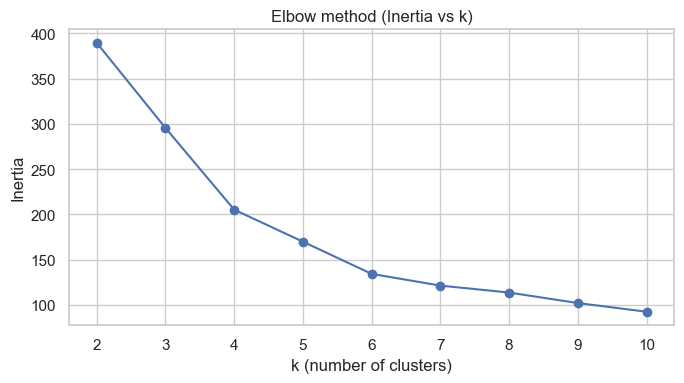

In [5]:
ks = range(2, 11)
inertias = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(ks), inertias, marker='o')
plt.title('Elbow method (Inertia vs k)')
plt.xlabel('k (number of clusters)')
plt.ylabel('Inertia')
plt.xticks(list(ks))
plt.tight_layout()
plt.show()

## Step 3 — Choose k with Silhouette Score
Silhouette measures how well-separated clusters are. Higher is better.

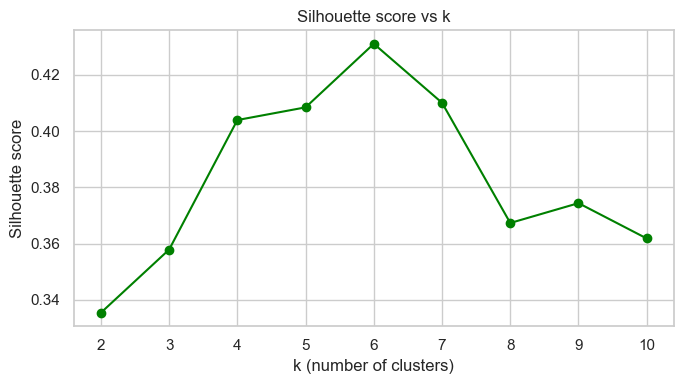

6

In [6]:
sil_scores = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    sil_scores.append(sil)

plt.figure(figsize=(7, 4))
plt.plot(list(ks), sil_scores, marker='o', color='green')
plt.title('Silhouette score vs k')
plt.xlabel('k (number of clusters)')
plt.ylabel('Silhouette score')
plt.xticks(list(ks))
plt.tight_layout()
plt.show()

best_k = int(list(ks)[int(np.argmax(sil_scores))])
best_k

## Step 4 — Fit final KMeans and visualize clusters
We fit KMeans with the selected k and create simple plots.

In [7]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init='auto')
clusters = kmeans.fit_predict(X_scaled)

df_result = df.copy()
df_result['Cluster'] = clusters

df_result['Cluster'].value_counts().sort_index()

Cluster
0    45
1    39
2    25
3    40
4    30
5    21
Name: count, dtype: int64

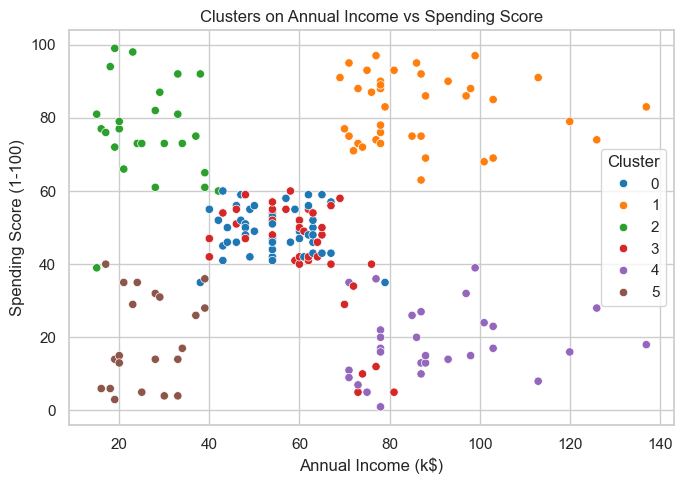

In [8]:
# If the classic 2D columns exist, plot them (Mall Customers usually has these names)
x_col = 'Annual Income (k$)' if 'Annual Income (k$)' in df_result.columns else None
y_col = 'Spending Score (1-100)' if 'Spending Score (1-100)' in df_result.columns else None

if x_col and y_col:
    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=df_result, x=x_col, y=y_col, hue='Cluster', palette='tab10')
    plt.title('Clusters on Annual Income vs Spending Score')
    plt.tight_layout()
    plt.show()
else:
    print('Columns for classic plot not found; using PCA plot instead.')

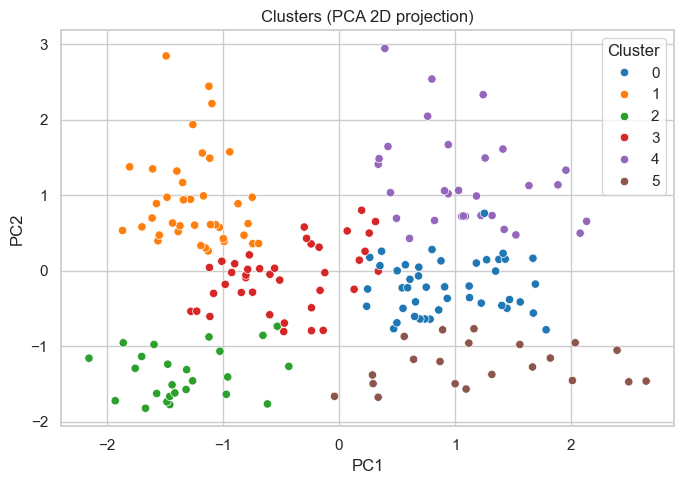

In [9]:
# General visualization using PCA to 2D (works for any number of features)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = clusters

plt.figure(figsize=(7, 5))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster', palette='tab10')
plt.title('Clusters (PCA 2D projection)')
plt.tight_layout()
plt.show()

## (Optional) Another practice: Hierarchical Clustering
We can also use a dendrogram to *visually* choose the number of clusters.

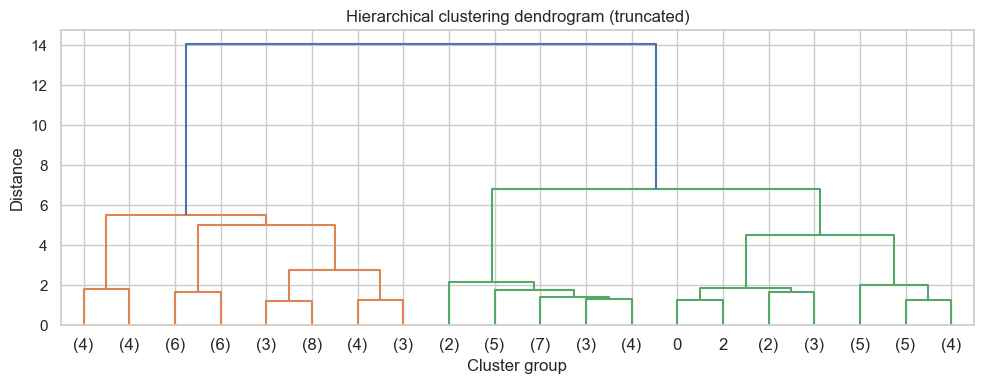

In [10]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Use a smaller sample for a readable dendrogram (otherwise it can be too dense)
sample_n = min(80, X_scaled.shape[0])
Z = linkage(X_scaled[:sample_n], method='ward')

plt.figure(figsize=(10, 4))
dendrogram(Z, truncate_mode='lastp', p=20)
plt.title('Hierarchical clustering dendrogram (truncated)')
plt.xlabel('Cluster group')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()